# Final Report Results Notebook

This notebook turns the completed Phase 4 and Phase 5 artifacts into report-ready tables and figures.

It follows `project_plan.md` Section 6:

- report both per-row F1 and per-order F1
- compare precision, recall, ROC-AUC, PR-AUC, and accuracy as supplementary metrics
- decompose FP/FN errors
- analyze model disagreement and error overlap
- slice errors by Phase 1 subgroups
- compare built-in feature importance across models

Note: the project plan also describes permutation importance and retraining ablations. Those artifacts are not present in the current repository, so this notebook does not claim those analyses. It limits feature analysis to saved built-in importance files.

In [1]:
from pathlib import Path
from itertools import combinations
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score

warnings.filterwarnings("ignore")

if Path.cwd().name == "src":
    ROOT = Path.cwd().parent
else:
    ROOT = Path.cwd()

RES = ROOT / "results"
TBL = RES / "report_tables"
PLOT = ROOT / "plots" / "report"
TBL.mkdir(parents=True, exist_ok=True)
PLOT.mkdir(parents=True, exist_ok=True)

MODELS = ["last_basket", "logreg", "rf", "adaboost", "xgboost"]
ML_MODELS = ["logreg", "rf", "adaboost", "xgboost"]
LABELS = {
    "last_basket": "Last Basket",
    "logreg": "Logistic Regression",
    "rf": "Random Forest",
    "adaboost": "AdaBoost",
    "xgboost": "XGBoost",
}
COLORS = {
    "last_basket": "#7f7f7f",
    "logreg": "#4e79a7",
    "rf": "#f28e2b",
    "adaboost": "#e15759",
    "xgboost": "#59a14f",
}

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
})

print("Root:", ROOT)
print("Tables:", TBL)
print("Plots:", PLOT)

Root: /Users/davidlee/Desktop/NYU 2026 Spring/1003/1003_final_project/instacart
Tables: /Users/davidlee/Desktop/NYU 2026 Spring/1003/1003_final_project/instacart/results/report_tables
Plots: /Users/davidlee/Desktop/NYU 2026 Spring/1003/1003_final_project/instacart/plots/report


## Load Final Artifacts

In [2]:
required = [
    RES / "test_predictions.parquet",
    RES / "metrics_summary.csv",
    RES / "model_disagreement.csv",
    RES / "basket_metrics.csv",
    RES / "behavioral_error_tags.csv",
    RES / "tables" / "final_model_comparison.csv",
    RES / "tables" / "final_mcnemar_bonferroni.csv",
    RES / "tables" / "final_bootstrap_f1_diff.csv",
    RES / "tables" / "final_delong_roc_auc.csv",
]
missing = [p for p in required if not p.exists()]
if missing:
    raise FileNotFoundError("Missing required artifacts:\n" + "\n".join(str(p) for p in missing))

master = pd.read_parquet(RES / "test_predictions.parquet")
metrics = pd.read_csv(RES / "metrics_summary.csv")
disagreement = pd.read_csv(RES / "model_disagreement.csv")
basket = pd.read_csv(RES / "basket_metrics.csv")
tags = pd.read_csv(RES / "behavioral_error_tags.csv", low_memory=False)

final_comparison = pd.read_csv(RES / "tables" / "final_model_comparison.csv")
mcnemar = pd.read_csv(RES / "tables" / "final_mcnemar_bonferroni.csv")
bootstrap = pd.read_csv(RES / "tables" / "final_bootstrap_f1_diff.csv")
delong = pd.read_csv(RES / "tables" / "final_delong_roc_auc.csv")

subgroup_cols = [
    "is_cold_start_user",
    "is_none_user",
    "is_high_variance_aisle",
    "is_single_purchase_pair",
    "primary_user_subgroup",
]
assert master[subgroup_cols].isna().sum().sum() == 0
assert set(metrics["model"]) == set(MODELS)

print("master:", master.shape)
print("metrics:", metrics.shape)
print("disagreement:", disagreement.shape)
print("basket:", basket.shape)
print("behavioral tags:", tags.shape)

master: (75000, 39)
metrics: (5, 20)
disagreement: (22194, 19)
basket: (32420, 19)
behavioral tags: (375000, 27)


## Table 1: Model Performance Summary

The plan asks for both global per-row F1 and Kaggle-style per-order F1. The table below keeps both visible. In these controlled final results, Random Forest is best by row-level F1 and ROC-AUC, XGBoost is best by PR-AUC, and Logistic Regression is best by per-order F1.

In [3]:
metric_cols = [
    "model", "model_label", "threshold", "n_rows", "n_users", "positive_rate",
    "accuracy", "precision", "recall", "f1", "per_order_f1", "roc_auc", "pr_auc",
    "avg_true_basket_size", "avg_pred_basket_size", "basket_size_mae",
    "basket_inflation_rate", "large_basket_inflation_rate", "none_collapse_rate",
]
report_metrics = metrics[metric_cols].copy().sort_values("f1", ascending=False)
report_metrics.to_csv(TBL / "report_model_metrics.csv", index=False)

display(
    report_metrics.style
        .format({
            "threshold": "{:.2f}",
            "positive_rate": "{:.3f}",
            "accuracy": "{:.4f}",
            "precision": "{:.4f}",
            "recall": "{:.4f}",
            "f1": "{:.4f}",
            "per_order_f1": "{:.4f}",
            "roc_auc": "{:.4f}",
            "pr_auc": "{:.4f}",
            "avg_true_basket_size": "{:.2f}",
            "avg_pred_basket_size": "{:.2f}",
            "basket_size_mae": "{:.2f}",
            "basket_inflation_rate": "{:.3f}",
            "large_basket_inflation_rate": "{:.3f}",
            "none_collapse_rate": "{:.3f}",
        })
        .highlight_max(subset=["f1", "per_order_f1", "roc_auc", "pr_auc"], color="#d8f3dc")
        .set_caption("Table 1. Controlled final model performance.")
)
print("Saved:", TBL / "report_model_metrics.csv")

,model,model_label,threshold,n_rows,n_users,positive_rate,accuracy,precision,recall,f1,per_order_f1,roc_auc,pr_auc,avg_true_basket_size,avg_pred_basket_size,basket_size_mae,basket_inflation_rate,large_basket_inflation_rate,none_collapse_rate
0,rf,Random Forest,0.43,75000,6484,0.125,0.8740,0.4970,0.6642,0.5686,0.2425,0.9073,0.5845,1.45,1.93,0.92,0.287,0.089,0.472
1,adaboost,AdaBoost,0.45,75000,6484,0.125,0.8685,0.4816,0.6774,0.5630,0.2414,0.9020,0.5738,1.45,2.03,0.99,0.304,0.101,0.464
2,xgboost,XGBoost,0.47,75000,6484,0.125,0.8668,0.4768,0.6746,0.5587,0.2390,0.9046,0.5854,1.45,2.05,1.01,0.304,0.105,0.467
3,logreg,Logistic Regression,0.50,75000,6484,0.125,0.7608,0.3132,0.7658,0.4446,0.2479,0.8429,0.4707,1.45,3.54,2.32,0.645,0.299,0.194
4,last_basket,Last Basket,1.00,75000,6484,0.125,0.7639,0.2777,0.5547,0.3701,0.2068,0.7573,0.2488,1.45,2.89,2.14,0.505,0.216,0.200


Saved: /Users/davidlee/Desktop/NYU 2026 Spring/1003/1003_final_project/instacart/results/report_tables/report_model_metrics.csv


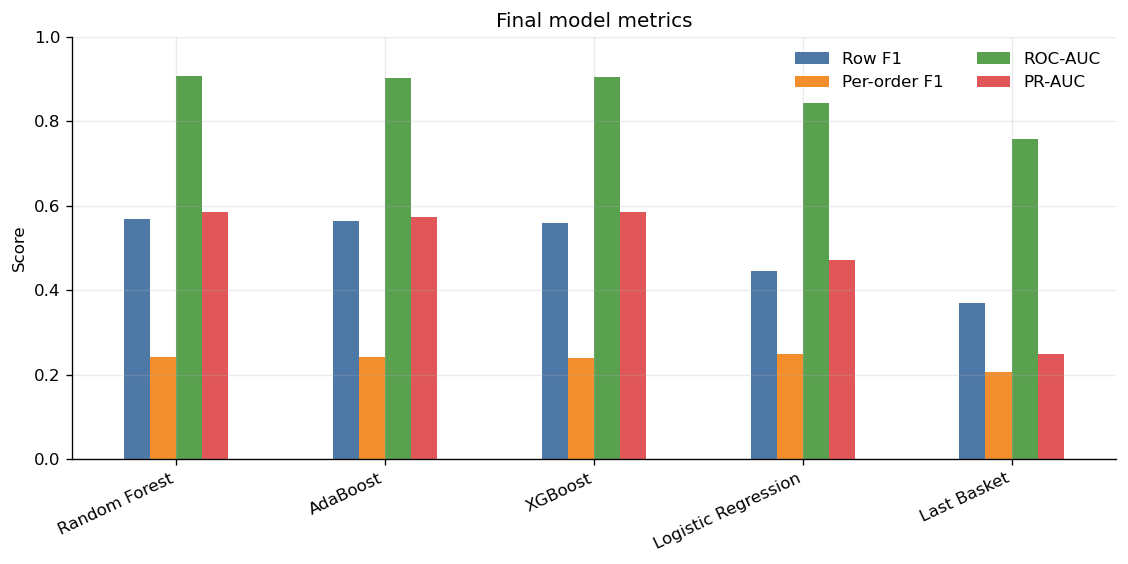

Saved: /Users/davidlee/Desktop/NYU 2026 Spring/1003/1003_final_project/instacart/plots/report/01_model_metrics.png


In [4]:
plot_df = report_metrics.set_index("model_label")[["f1", "per_order_f1", "roc_auc", "pr_auc"]]
ax = plot_df.plot(kind="bar", figsize=(9.5, 4.8), color=["#4e79a7", "#f28e2b", "#59a14f", "#e15759"])
ax.set_title("Final model metrics")
ax.set_xlabel("")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(["Row F1", "Per-order F1", "ROC-AUC", "PR-AUC"], ncol=2, frameon=False)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(PLOT / "01_model_metrics.png")
plt.show()
print("Saved:", PLOT / "01_model_metrics.png")

## Table 2: Confusion-Matrix Decomposition

In [5]:
rows = []
for model in MODELS:
    err = master[f"{model}_error_type"]
    y = master["label"].astype(int)
    tp = int((err == "TP").sum())
    fp = int((err == "FP").sum())
    fn = int((err == "FN").sum())
    tn = int((err == "TN").sum())
    n_pos = int((y == 1).sum())
    n_neg = int((y == 0).sum())
    rows.append({
        "model": model,
        "model_label": LABELS[model],
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
        "miss_rate": fn / n_pos,
        "false_alarm_rate": fp / n_neg,
        "predicted_positive_rate": int(master[f"{model}_pred"].sum()) / len(master),
    })
confusion_report = pd.DataFrame(rows)
confusion_report.to_csv(TBL / "report_confusion_decomposition.csv", index=False)
display(
    confusion_report.style
        .format({
            "miss_rate": "{:.3f}",
            "false_alarm_rate": "{:.3f}",
            "predicted_positive_rate": "{:.3f}",
        })
        .background_gradient(subset=["miss_rate"], cmap="Reds")
        .background_gradient(subset=["false_alarm_rate"], cmap="Oranges")
        .set_caption("Table 2. Error decomposition. Miss rate = FN / positives; false alarm rate = FP / negatives.")
)
print("Saved:", TBL / "report_confusion_decomposition.csv")

,model,model_label,tp,fp,fn,tn,miss_rate,false_alarm_rate,predicted_positive_rate
0,last_basket,Last Basket,5202,13531,4176,52091,0.445,0.206,0.250
1,logreg,Logistic Regression,7182,15746,2196,49876,0.234,0.240,0.306
2,rf,Random Forest,6229,6303,3149,59319,0.336,0.096,0.167
3,adaboost,AdaBoost,6353,6838,3025,58784,0.323,0.104,0.176
4,xgboost,XGBoost,6326,6941,3052,58681,0.325,0.106,0.177


Saved: /Users/davidlee/Desktop/NYU 2026 Spring/1003/1003_final_project/instacart/results/report_tables/report_confusion_decomposition.csv


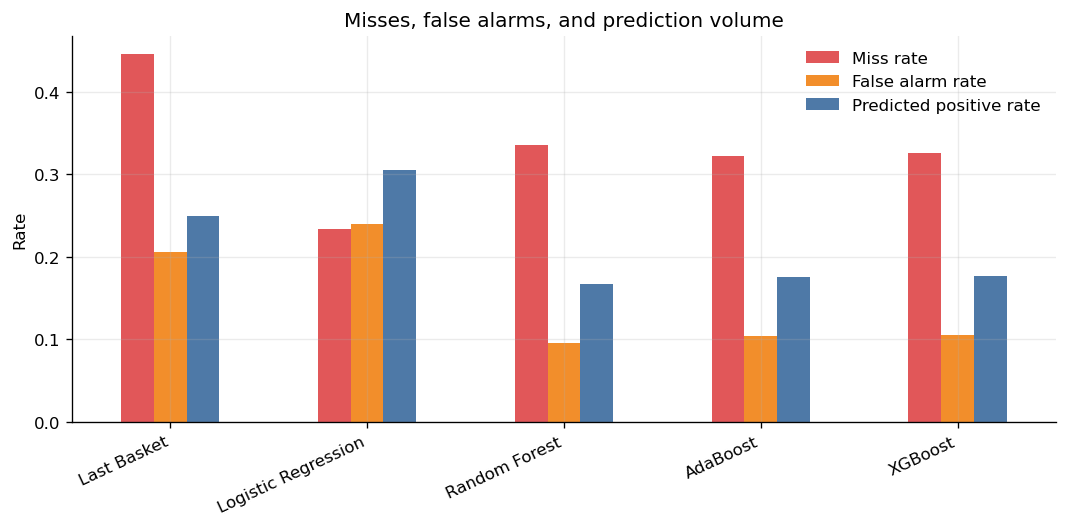

Saved: /Users/davidlee/Desktop/NYU 2026 Spring/1003/1003_final_project/instacart/plots/report/02_error_rates.png


In [6]:
plot_df = confusion_report.set_index("model_label")[["miss_rate", "false_alarm_rate", "predicted_positive_rate"]]
ax = plot_df.plot(kind="bar", figsize=(9, 4.5), color=["#e15759", "#f28e2b", "#4e79a7"])
ax.set_title("Misses, false alarms, and prediction volume")
ax.set_xlabel("")
ax.set_ylabel("Rate")
ax.legend(["Miss rate", "False alarm rate", "Predicted positive rate"], frameon=False)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(PLOT / "02_error_rates.png")
plt.show()
print("Saved:", PLOT / "02_error_rates.png")

## Table 3: Effect Sizes and Significance

In [7]:
rf = report_metrics.set_index("model").loc["rf"]
effect_rows = []
for _, row in report_metrics.iterrows():
    if row["model"] == "rf":
        continue
    effect_rows.append({
        "comparison": f"rf - {row['model']}",
        "row_f1_diff": rf["f1"] - row["f1"],
        "per_order_f1_diff": rf["per_order_f1"] - row["per_order_f1"],
        "roc_auc_diff": rf["roc_auc"] - row["roc_auc"],
        "pr_auc_diff": rf["pr_auc"] - row["pr_auc"],
    })
effect_sizes = pd.DataFrame(effect_rows)
effect_sizes.to_csv(TBL / "report_effect_sizes_vs_rf.csv", index=False)

mcnemar.to_csv(TBL / "report_mcnemar_bonferroni.csv", index=False)
bootstrap.to_csv(TBL / "report_bootstrap_f1_diff.csv", index=False)
delong.to_csv(TBL / "report_delong_roc_auc.csv", index=False)

display(effect_sizes.style.format({
    "row_f1_diff": "{:+.6f}",
    "per_order_f1_diff": "{:+.6f}",
    "roc_auc_diff": "{:+.6f}",
    "pr_auc_diff": "{:+.6f}",
}).set_caption("Table 3A. Raw RF effect sizes versus each model."))
display(bootstrap.style.format({"mean_diff": "{:+.6f}", "ci_low": "{:+.6f}", "ci_high": "{:+.6f}"}).set_caption("Table 3B. Bootstrap per-order F1 differences from existing controlled comparison."))
display(delong.style.format({"auc_a": "{:.6f}", "auc_b": "{:.6f}", "auc_diff": "{:+.6f}", "p": "{:.3e}"}).set_caption("Table 3C. DeLong ROC-AUC tests from existing controlled comparison."))
print("Saved significance/effect-size tables under:", TBL)

,comparison,row_f1_diff,per_order_f1_diff,roc_auc_diff,pr_auc_diff
0,rf - adaboost,+0.005614,+0.001086,+0.005345,+0.010699
1,rf - xgboost,+0.009888,+0.003473,+0.002715,-0.000886
2,rf - logreg,+0.123976,-0.005463,+0.064462,+0.113781
3,rf - last_basket,+0.198495,+0.035705,+0.150086,+0.335672


,model_a,model_b,metric,mean_diff,ci_low,ci_high,significant_95
0,logreg,rf,mean_per_order_f1_diff_a_minus_b,+0.005463,+0.001744,+0.009648,True
1,logreg,adaboost,mean_per_order_f1_diff_a_minus_b,+0.006550,+0.002364,+0.010925,True
2,logreg,xgboost,mean_per_order_f1_diff_a_minus_b,+0.008936,+0.005116,+0.013153,True
3,rf,adaboost,mean_per_order_f1_diff_a_minus_b,+0.001086,-0.002384,+0.004441,False
4,rf,xgboost,mean_per_order_f1_diff_a_minus_b,+0.003473,+0.000501,+0.006416,True
5,adaboost,xgboost,mean_per_order_f1_diff_a_minus_b,+0.002386,-0.001716,+0.006472,False


,model_a,model_b,auc_a,auc_b,auc_diff,z,p,bonferroni_alpha,significant_bonferroni
0,logreg,rf,0.842885,0.907347,-0.064462,-52.330534,0.000e+00,0.008333,True
1,logreg,adaboost,0.842885,0.902003,-0.059117,-45.114099,0.000e+00,0.008333,True
2,logreg,xgboost,0.842885,0.904632,-0.061746,-45.751917,0.000e+00,0.008333,True
3,rf,adaboost,0.907347,0.902003,+0.005345,8.685665,3.765e-18,0.008333,True
4,rf,xgboost,0.907347,0.904632,+0.002715,5.382179,7.359e-08,0.008333,True
5,adaboost,xgboost,0.902003,0.904632,-0.002629,-3.397324,6.805e-04,0.008333,True


Saved significance/effect-size tables under: /Users/davidlee/Desktop/NYU 2026 Spring/1003/1003_final_project/instacart/results/report_tables


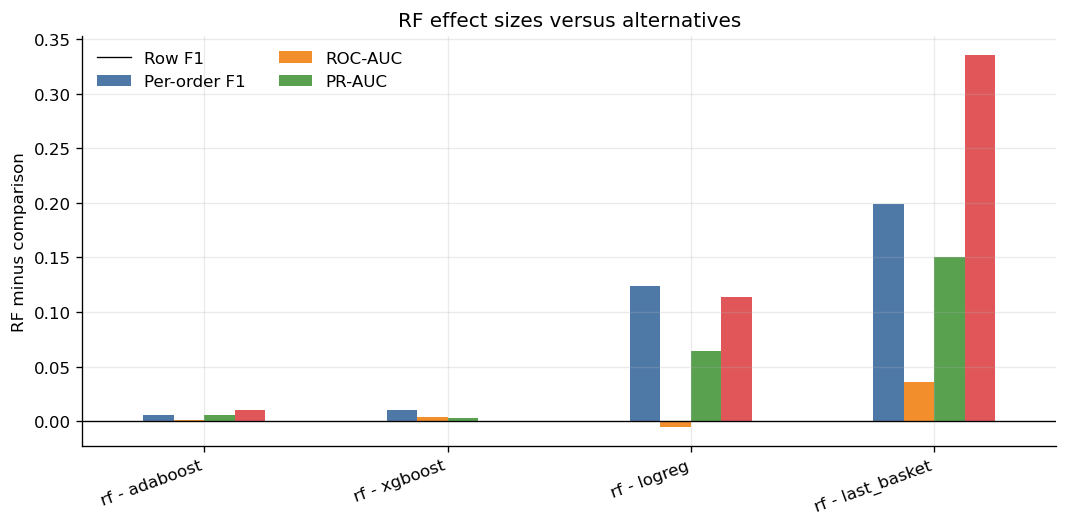

Saved: /Users/davidlee/Desktop/NYU 2026 Spring/1003/1003_final_project/instacart/plots/report/03_effect_sizes_vs_rf.png


In [8]:
ax = effect_sizes.set_index("comparison")[["row_f1_diff", "per_order_f1_diff", "roc_auc_diff", "pr_auc_diff"]].plot(
    kind="bar", figsize=(9, 4.5), color=["#4e79a7", "#f28e2b", "#59a14f", "#e15759"]
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("RF effect sizes versus alternatives")
ax.set_xlabel("")
ax.set_ylabel("RF minus comparison")
ax.legend(["Row F1", "Per-order F1", "ROC-AUC", "PR-AUC"], ncol=2, frameon=False)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(PLOT / "03_effect_sizes_vs_rf.png")
plt.show()
print("Saved:", PLOT / "03_effect_sizes_vs_rf.png")

## Table 4: Basket-Level Metrics

In [9]:
basket_summary = (
    basket.groupby(["model", "model_label"])
    .agg(
        n_users=("user_id", "nunique"),
        mean_true_basket_size=("true_basket_size", "mean"),
        mean_pred_basket_size=("pred_basket_size", "mean"),
        mean_per_order_f1=("per_order_f1", "mean"),
        median_per_order_f1=("per_order_f1", "median"),
        basket_size_mae=("basket_size_abs_error", "mean"),
        basket_inflation_rate=("basket_size_inflation", "mean"),
        large_basket_inflation_rate=("basket_size_inflation_large", "mean"),
        none_collapse_rate=("none_collapse_case", "mean"),
    )
    .reset_index()
    .sort_values("mean_per_order_f1", ascending=False)
)
basket_summary.to_csv(TBL / "report_basket_summary.csv", index=False)
display(
    basket_summary.style
        .format({
            "mean_true_basket_size": "{:.2f}",
            "mean_pred_basket_size": "{:.2f}",
            "mean_per_order_f1": "{:.4f}",
            "median_per_order_f1": "{:.4f}",
            "basket_size_mae": "{:.2f}",
            "basket_inflation_rate": "{:.3f}",
            "large_basket_inflation_rate": "{:.3f}",
            "none_collapse_rate": "{:.3f}",
        })
        .highlight_max(subset=["mean_per_order_f1"], color="#d8f3dc")
        .set_caption("Table 4. Basket-level metrics by model.")
)
print("Saved:", TBL / "report_basket_summary.csv")

,model,model_label,n_users,mean_true_basket_size,mean_pred_basket_size,mean_per_order_f1,median_per_order_f1,basket_size_mae,basket_inflation_rate,large_basket_inflation_rate,none_collapse_rate
2,logreg,Logistic Regression,6484,1.45,3.54,0.2479,0.0000,2.32,0.645,0.299,0.194
3,rf,Random Forest,6484,1.45,1.93,0.2425,0.0000,0.92,0.287,0.089,0.472
0,adaboost,AdaBoost,6484,1.45,2.03,0.2414,0.0000,0.99,0.304,0.101,0.464
4,xgboost,XGBoost,6484,1.45,2.05,0.2390,0.0000,1.01,0.304,0.105,0.467
1,last_basket,Last Basket,6484,1.45,2.89,0.2068,0.0000,2.14,0.505,0.216,0.200


Saved: /Users/davidlee/Desktop/NYU 2026 Spring/1003/1003_final_project/instacart/results/report_tables/report_basket_summary.csv


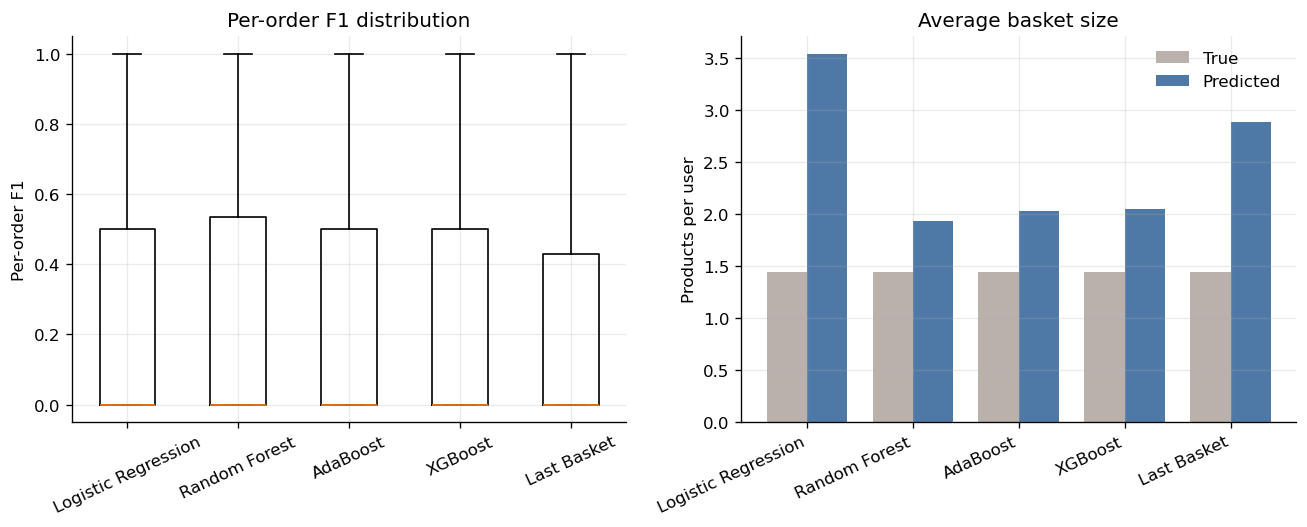

Saved: /Users/davidlee/Desktop/NYU 2026 Spring/1003/1003_final_project/instacart/plots/report/04_basket_metrics.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

order = basket_summary.sort_values("mean_per_order_f1", ascending=False)["model"].tolist()
data = [basket.loc[basket["model"] == m, "per_order_f1"].to_numpy() for m in order]
axes[0].boxplot(data, labels=[LABELS[m] for m in order], showfliers=False)
axes[0].set_title("Per-order F1 distribution")
axes[0].set_ylabel("Per-order F1")
axes[0].tick_params(axis="x", rotation=25)

width = 0.38
x = np.arange(len(order))
true_vals = [basket_summary.set_index("model").loc[m, "mean_true_basket_size"] for m in order]
pred_vals = [basket_summary.set_index("model").loc[m, "mean_pred_basket_size"] for m in order]
axes[1].bar(x - width/2, true_vals, width, label="True", color="#bab0ac")
axes[1].bar(x + width/2, pred_vals, width, label="Predicted", color="#4e79a7")
axes[1].set_title("Average basket size")
axes[1].set_ylabel("Products per user")
axes[1].set_xticks(x, [LABELS[m] for m in order], rotation=25, ha="right")
axes[1].legend(frameon=False)

plt.tight_layout()
plt.savefig(PLOT / "04_basket_metrics.png")
plt.show()
print("Saved:", PLOT / "04_basket_metrics.png")

## Table 5: Model Disagreement and Error Overlap

In [11]:
pred_cols = {m: f"{m}_pred" for m in MODELS}
err_cols = {m: f"{m}_error_type" for m in MODELS}

disagree_mat = pd.DataFrame(index=MODELS, columns=MODELS, dtype=float)
overlap_rows = []
for a, b in combinations(MODELS, 2):
    a_pred = master[pred_cols[a]].to_numpy()
    b_pred = master[pred_cols[b]].to_numpy()
    a_err = ~master[err_cols[a]].isin(["TP", "TN"]).to_numpy()
    b_err = ~master[err_cols[b]].isin(["TP", "TN"]).to_numpy()

    disagree = float((a_pred != b_pred).mean())
    disagree_mat.loc[a, b] = disagree
    disagree_mat.loc[b, a] = disagree

    both_error = float((a_err & b_err).mean())
    a_only = float((a_err & ~b_err).mean())
    b_only = float((~a_err & b_err).mean())
    both_correct = float((~a_err & ~b_err).mean())
    union_error = float((a_err | b_err).mean())
    overlap_rows.append({
        "model_a": a,
        "model_b": b,
        "prediction_disagreement_rate": disagree,
        "both_error_rate": both_error,
        "model_a_only_error_rate": a_only,
        "model_b_only_error_rate": b_only,
        "both_correct_rate": both_correct,
        "error_jaccard": both_error / union_error if union_error else np.nan,
    })
np.fill_diagonal(disagree_mat.values, 0)
disagree_mat.index = [LABELS[m] for m in MODELS]
disagree_mat.columns = [LABELS[m] for m in MODELS]
disagreement_matrix = disagree_mat.reset_index().rename(columns={"index": "model"})
disagreement_matrix.to_csv(TBL / "report_prediction_disagreement_matrix.csv", index=False)

error_overlap = pd.DataFrame(overlap_rows)
error_overlap.to_csv(TBL / "report_pairwise_error_overlap.csv", index=False)
display(error_overlap.style.format({
    "prediction_disagreement_rate": "{:.3f}",
    "both_error_rate": "{:.3f}",
    "model_a_only_error_rate": "{:.3f}",
    "model_b_only_error_rate": "{:.3f}",
    "both_correct_rate": "{:.3f}",
    "error_jaccard": "{:.3f}",
}).set_caption("Table 5. Pairwise prediction disagreement and error overlap."))
print("Saved:", TBL / "report_pairwise_error_overlap.csv")

,model_a,model_b,prediction_disagreement_rate,both_error_rate,model_a_only_error_rate,model_b_only_error_rate,both_correct_rate,error_jaccard
0,last_basket,logreg,0.190,0.143,0.093,0.097,0.667,0.429
1,last_basket,rf,0.199,0.082,0.154,0.044,0.720,0.292
2,last_basket,adaboost,0.202,0.083,0.153,0.049,0.715,0.291
3,last_basket,xgboost,0.207,0.081,0.155,0.052,0.712,0.282
4,logreg,rf,0.154,0.106,0.133,0.020,0.741,0.408
5,logreg,adaboost,0.157,0.107,0.132,0.025,0.736,0.405
6,logreg,xgboost,0.162,0.105,0.134,0.028,0.733,0.395
7,rf,adaboost,0.049,0.104,0.022,0.027,0.847,0.682
8,rf,xgboost,0.041,0.109,0.017,0.024,0.850,0.724
9,adaboost,xgboost,0.062,0.101,0.030,0.032,0.837,0.619


Saved: /Users/davidlee/Desktop/NYU 2026 Spring/1003/1003_final_project/instacart/results/report_tables/report_pairwise_error_overlap.csv


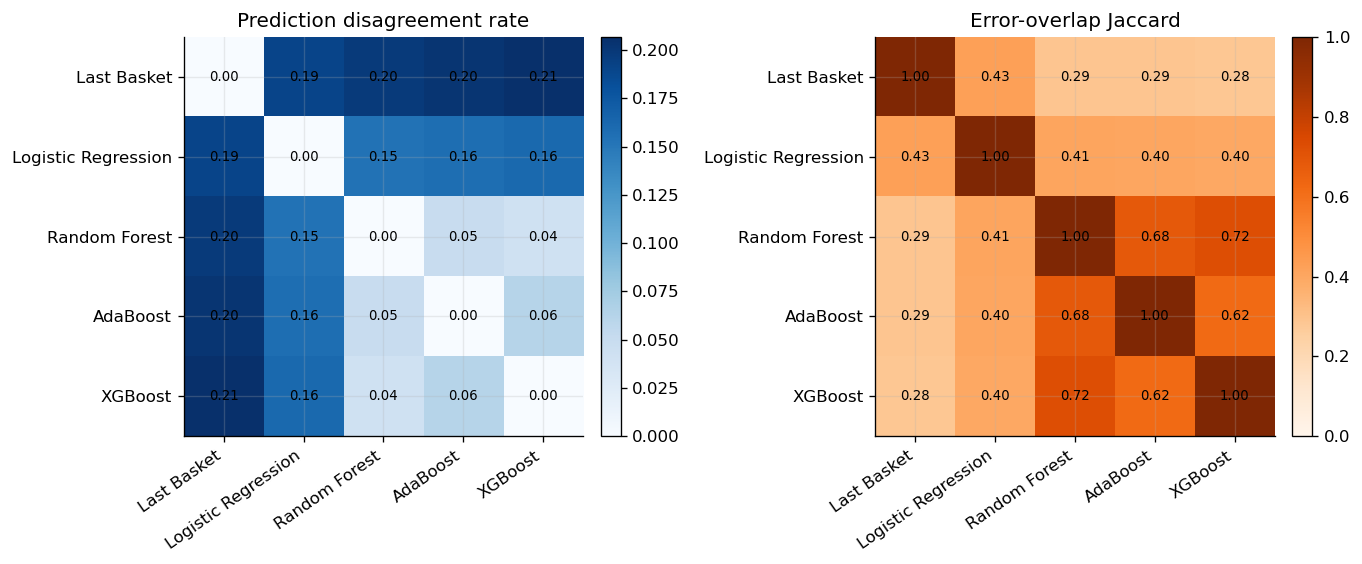

Saved: /Users/davidlee/Desktop/NYU 2026 Spring/1003/1003_final_project/instacart/plots/report/05_model_disagreement_overlap.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))

im0 = axes[0].imshow(disagree_mat.values.astype(float), cmap="Blues", vmin=0, vmax=np.nanmax(disagree_mat.values.astype(float)))
axes[0].set_title("Prediction disagreement rate")
axes[0].set_xticks(range(len(MODELS)), [LABELS[m] for m in MODELS], rotation=35, ha="right")
axes[0].set_yticks(range(len(MODELS)), [LABELS[m] for m in MODELS])
for i in range(len(MODELS)):
    for j in range(len(MODELS)):
        axes[0].text(j, i, f"{disagree_mat.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

jaccard = pd.DataFrame(index=MODELS, columns=MODELS, dtype=float)
for _, row in error_overlap.iterrows():
    jaccard.loc[row["model_a"], row["model_b"]] = row["error_jaccard"]
    jaccard.loc[row["model_b"], row["model_a"]] = row["error_jaccard"]
np.fill_diagonal(jaccard.values, 1)
im1 = axes[1].imshow(jaccard.values.astype(float), cmap="Oranges", vmin=0, vmax=1)
axes[1].set_title("Error-overlap Jaccard")
axes[1].set_xticks(range(len(MODELS)), [LABELS[m] for m in MODELS], rotation=35, ha="right")
axes[1].set_yticks(range(len(MODELS)), [LABELS[m] for m in MODELS])
for i in range(len(MODELS)):
    for j in range(len(MODELS)):
        axes[1].text(j, i, f"{jaccard.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(PLOT / "05_model_disagreement_overlap.png")
plt.show()
print("Saved:", PLOT / "05_model_disagreement_overlap.png")

In [13]:
disagreement_examples = (
    disagreement.sort_values(["n_models_pred_positive", "prob_range"], ascending=[False, False])
    .head(30)
    .copy()
)
disagreement_examples.to_csv(TBL / "report_disagreement_examples.csv", index=False)
display(disagreement_examples.head(10))
print("Saved:", TBL / "report_disagreement_examples.csv")

,user_id,product_id,label,last_basket_pred,logreg_pred,rf_pred,adaboost_pred,xgboost_pred,last_basket_prob,logreg_prob,rf_prob,adaboost_prob,xgboost_prob,n_models_pred_positive,n_models_pred_negative,prob_range,models_pred_positive,models_pred_negative,disagreement_type
0,173850,20463,0,1,1,1,1,0,1.0,0.761635,0.488886,0.474054,0.100419,4,1,0.899581,last_basket;logreg;rf;adaboost,xgboost,split_vote
1,63948,34300,0,1,1,1,1,0,1.0,0.650840,0.456683,0.462011,0.104779,4,1,0.895221,last_basket;logreg;rf;adaboost,xgboost,split_vote
2,47413,20119,0,1,1,1,1,0,1.0,0.671700,0.432158,0.452458,0.116659,4,1,0.883341,last_basket;logreg;rf;adaboost,xgboost,split_vote
3,80032,38185,1,1,1,1,1,0,1.0,0.513302,0.431849,0.455067,0.135408,4,1,0.864592,last_basket;logreg;rf;adaboost,xgboost,split_vote
4,190153,32553,0,1,1,1,1,0,1.0,0.732412,0.431566,0.455977,0.151530,4,1,0.848470,last_basket;logreg;rf;adaboost,xgboost,split_vote
5,204961,5373,0,1,1,1,1,0,1.0,0.613944,0.459966,0.462836,0.155629,4,1,0.844371,last_basket;logreg;rf;adaboost,xgboost,split_vote
6,138246,38456,0,1,1,1,1,0,1.0,0.707156,0.526915,0.460829,0.159229,4,1,0.840771,last_basket;logreg;rf;adaboost,xgboost,split_vote
7,157520,47626,0,1,1,1,1,0,1.0,0.912474,0.472103,0.475589,0.160099,4,1,0.839901,last_basket;logreg;rf;adaboost,xgboost,split_vote
8,138246,36550,0,1,1,1,1,0,1.0,0.607306,0.437038,0.481077,0.181252,4,1,0.818748,last_basket;logreg;rf;adaboost,xgboost,split_vote
9,111112,35142,1,1,1,1,1,0,1.0,0.613494,0.464027,0.459923,0.184264,4,1,0.815736,last_basket;logreg;rf;adaboost,xgboost,split_vote


Saved: /Users/davidlee/Desktop/NYU 2026 Spring/1003/1003_final_project/instacart/results/report_tables/report_disagreement_examples.csv


## Table 6: Subgroup Error Analysis

In [14]:
subgroup_rows = []
for model in MODELS:
    for subgroup, g in master.groupby("primary_user_subgroup"):
        y = g["label"].astype(int).to_numpy()
        pred = g[f"{model}_pred"].astype(int).to_numpy()
        err = g[f"{model}_error_type"]
        n_pos = int((y == 1).sum())
        n_neg = int((y == 0).sum())
        subgroup_rows.append({
            "model": model,
            "model_label": LABELS[model],
            "subgroup": subgroup,
            "n_rows": len(g),
            "n_users": g["user_id"].nunique(),
            "positive_rate": y.mean() if len(y) else np.nan,
            "precision": precision_score(y, pred, zero_division=0),
            "recall": recall_score(y, pred, zero_division=0),
            "f1": f1_score(y, pred, zero_division=0),
            "miss_rate": int((err == "FN").sum()) / n_pos if n_pos else np.nan,
            "false_alarm_rate": int((err == "FP").sum()) / n_neg if n_neg else np.nan,
        })
subgroup_metrics = pd.DataFrame(subgroup_rows)
subgroup_metrics.to_csv(TBL / "report_subgroup_metrics.csv", index=False)
display(
    subgroup_metrics.sort_values(["subgroup", "f1"], ascending=[True, False])
    .style
    .format({
        "positive_rate": "{:.3f}",
        "precision": "{:.3f}",
        "recall": "{:.3f}",
        "f1": "{:.3f}",
        "miss_rate": "{:.3f}",
        "false_alarm_rate": "{:.3f}",
    })
    .background_gradient(subset=["f1"], cmap="Greens")
    .set_caption("Table 6. Row-level subgroup metrics by primary user subgroup.")
)
print("Saved:", TBL / "report_subgroup_metrics.csv")

,model,model_label,subgroup,n_rows,n_users,positive_rate,precision,recall,f1,miss_rate,false_alarm_rate
0,last_basket,Last Basket,cold_start_none_user,1753,203,0.000,0.000,0.000,0.000,nan,0.398
4,logreg,Logistic Regression,cold_start_none_user,1753,203,0.000,0.000,0.000,0.000,nan,0.185
8,rf,Random Forest,cold_start_none_user,1753,203,0.000,0.000,0.000,0.000,nan,0.027
12,adaboost,AdaBoost,cold_start_none_user,1753,203,0.000,0.000,0.000,0.000,nan,0.040
16,xgboost,XGBoost,cold_start_none_user,1753,203,0.000,0.000,0.000,0.000,nan,0.042
13,adaboost,AdaBoost,cold_start_user,1778,156,0.267,0.502,0.629,0.558,0.371,0.228
5,logreg,Logistic Regression,cold_start_user,1778,156,0.267,0.469,0.672,0.552,0.328,0.277
9,rf,Random Forest,cold_start_user,1778,156,0.267,0.543,0.549,0.546,0.451,0.169
17,xgboost,XGBoost,cold_start_user,1778,156,0.267,0.509,0.566,0.536,0.434,0.199
1,last_basket,Last Basket,cold_start_user,1778,156,0.267,0.372,0.684,0.482,0.316,0.421


Saved: /Users/davidlee/Desktop/NYU 2026 Spring/1003/1003_final_project/instacart/results/report_tables/report_subgroup_metrics.csv


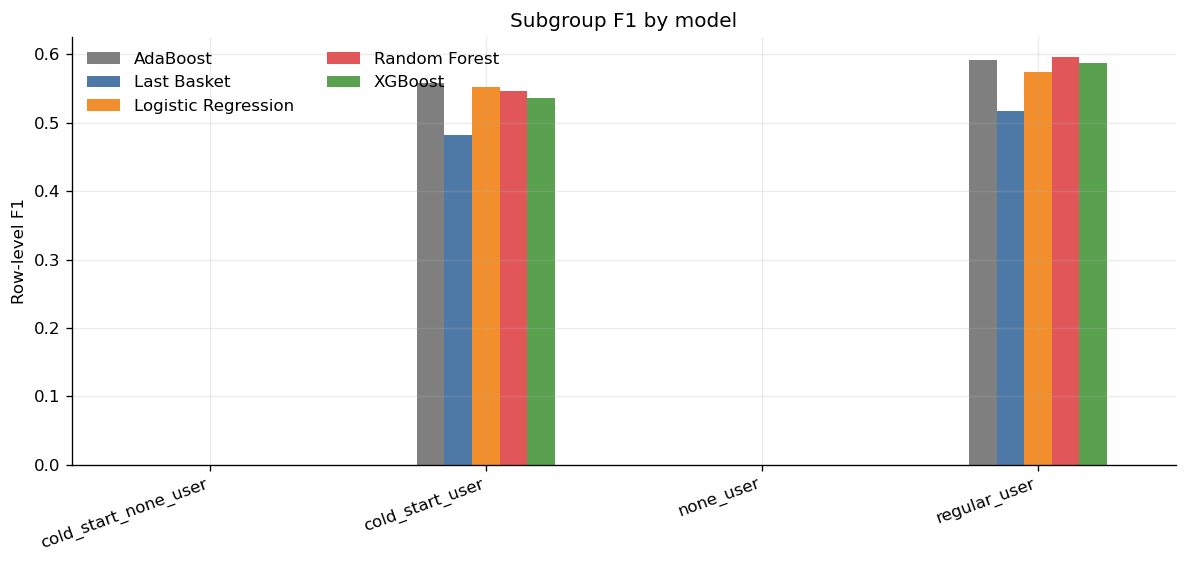

Saved: /Users/davidlee/Desktop/NYU 2026 Spring/1003/1003_final_project/instacart/plots/report/06_subgroup_f1.png


In [15]:
pivot = subgroup_metrics.pivot(index="subgroup", columns="model_label", values="f1")
ax = pivot.plot(kind="bar", figsize=(10, 4.8), color=[COLORS[m] for m in MODELS if LABELS[m] in pivot.columns])
ax.set_title("Subgroup F1 by model")
ax.set_xlabel("")
ax.set_ylabel("Row-level F1")
ax.legend(frameon=False, ncol=2)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(PLOT / "06_subgroup_f1.png")
plt.show()
print("Saved:", PLOT / "06_subgroup_f1.png")

## Table 7: Behavioral Error Tags

In [16]:
tag_counts = (
    tags.groupby(["model", "model_label", "behavioral_error_tag"])
    .size()
    .rename("n_rows")
    .reset_index()
)
totals = tags.groupby("model").size().rename("model_rows")
tag_counts = tag_counts.merge(totals, on="model", how="left")
tag_counts["share_of_model_rows"] = tag_counts["n_rows"] / tag_counts["model_rows"]
tag_counts = tag_counts.sort_values(["model", "n_rows"], ascending=[True, False])
tag_counts.to_csv(TBL / "report_behavioral_error_tags.csv", index=False)

display(
    tag_counts.style
    .format({"share_of_model_rows": "{:.3f}"})
    .set_caption("Table 7. Behavioral error-tag counts. Basket-level tags are repeated across the model's user-product rows.")
)
print("Saved:", TBL / "report_behavioral_error_tags.csv")

,model,model_label,behavioral_error_tag,n_rows,model_rows,share_of_model_rows
5,adaboost,AdaBoost,none_collapse_case,31199,75000,0.416
6,adaboost,AdaBoost,untagged,29221,75000,0.390
0,adaboost,AdaBoost,basket_size_inflation_error,9660,75000,0.129
4,adaboost,AdaBoost,fp_stockpile_error,2188,75000,0.029
3,adaboost,AdaBoost,fp_broken_streak_error,1236,75000,0.016
2,adaboost,AdaBoost,fn_sleeper_staple_error,897,75000,0.012
1,adaboost,AdaBoost,fn_new_habit_error,599,75000,0.008
14,last_basket,Last Basket,untagged,37942,75000,0.506
7,last_basket,Last Basket,basket_size_inflation_error,17842,75000,0.238
13,last_basket,Last Basket,none_collapse_case,8229,75000,0.110


Saved: /Users/davidlee/Desktop/NYU 2026 Spring/1003/1003_final_project/instacart/results/report_tables/report_behavioral_error_tags.csv


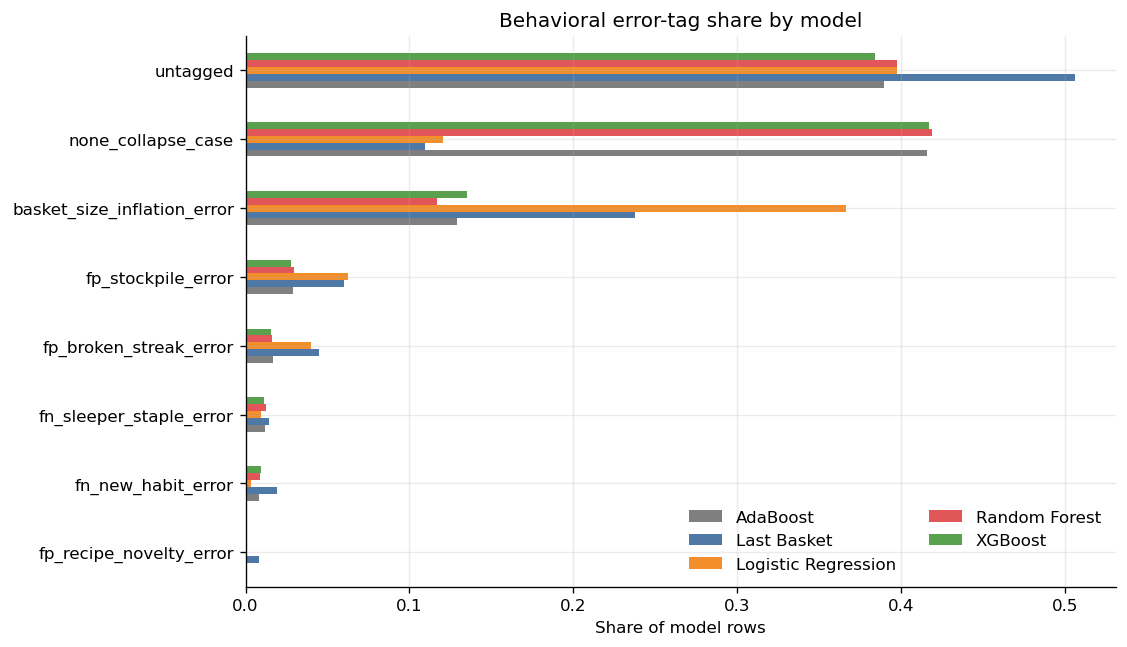

Saved: /Users/davidlee/Desktop/NYU 2026 Spring/1003/1003_final_project/instacart/plots/report/07_behavioral_error_tags.png


In [17]:
tag_pivot = tag_counts.pivot(index="behavioral_error_tag", columns="model_label", values="share_of_model_rows").fillna(0)
tag_pivot = tag_pivot.loc[tag_pivot.mean(axis=1).sort_values(ascending=True).index]
ax = tag_pivot.plot(kind="barh", figsize=(9.5, 5.5), color=[COLORS[m] for m in MODELS if LABELS[m] in tag_pivot.columns])
ax.set_title("Behavioral error-tag share by model")
ax.set_xlabel("Share of model rows")
ax.set_ylabel("")
ax.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.savefig(PLOT / "07_behavioral_error_tags.png")
plt.show()
print("Saved:", PLOT / "07_behavioral_error_tags.png")

## Table 8: Built-In Feature Importance Comparison

In [18]:
importance_frames = []
for model in ML_MODELS:
    path = RES / model / f"feature_importance_{model}.csv"
    if not path.exists():
        print("Missing:", path)
        continue
    imp = pd.read_csv(path)
    if "feature_name" not in imp.columns:
        imp = imp.rename(columns={imp.columns[0]: "feature_name", imp.columns[1]: "importance_score"})
    imp = imp[["feature_name", "importance_score"]].copy()
    imp["model"] = model
    imp["model_label"] = LABELS[model]
    imp["rank"] = imp["importance_score"].rank(method="first", ascending=False).astype(int)
    importance_frames.append(imp)

feature_importance = pd.concat(importance_frames, ignore_index=True)
top15_long = feature_importance[feature_importance["rank"] <= 15].sort_values(["model", "rank"])
top15_long.to_csv(TBL / "report_feature_top15_long.csv", index=False)
display(top15_long)
print("Saved:", TBL / "report_feature_top15_long.csv")

,feature_name,importance_score,model,model_label,rank
68,target_days_since_prior,0.216963,adaboost,AdaBoost,1
69,up_dow_purchase_count,0.215522,adaboost,AdaBoost,2
70,up_purchase_count_n5,0.136419,adaboost,AdaBoost,3
71,up_reorder_rate_after_first,0.076297,adaboost,AdaBoost,4
72,prod_reorder_probability,0.059357,adaboost,AdaBoost,5
73,target_hour,0.056978,adaboost,AdaBoost,6
74,up_orders_since_last,0.039900,adaboost,AdaBoost,7
75,target_dow,0.034829,adaboost,AdaBoost,8
76,up_days_since_last,0.026985,adaboost,AdaBoost,9
77,up_order_ratio_by_chance,0.024518,adaboost,AdaBoost,10


Saved: /Users/davidlee/Desktop/NYU 2026 Spring/1003/1003_final_project/instacart/results/report_tables/report_feature_top15_long.csv


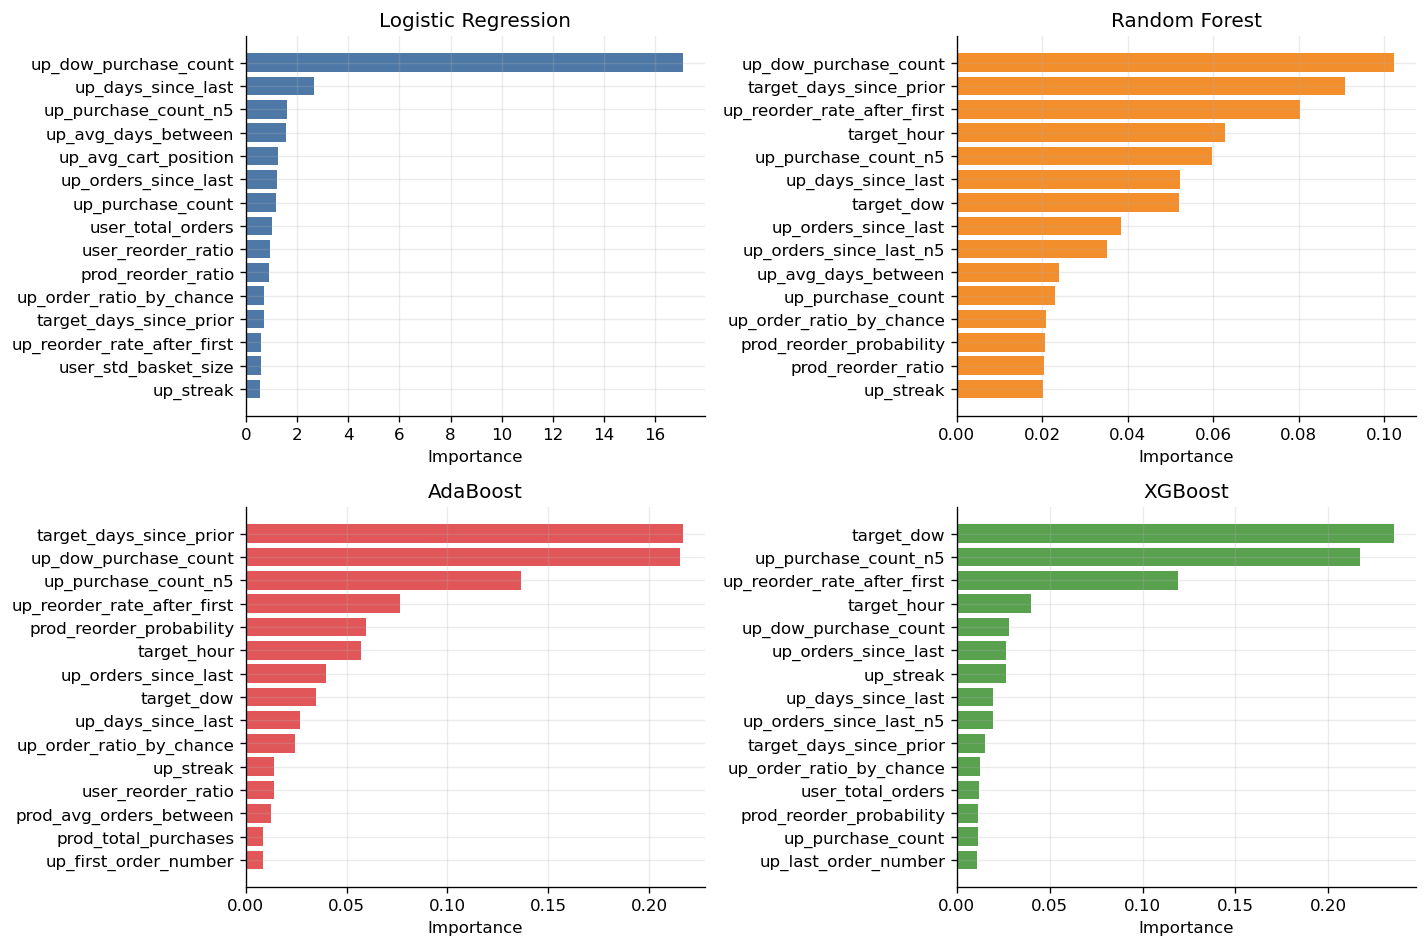

Saved: /Users/davidlee/Desktop/NYU 2026 Spring/1003/1003_final_project/instacart/plots/report/08_feature_importance_top15.png


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()
for ax, model in zip(axes, ML_MODELS):
    sub = feature_importance[feature_importance["model"] == model].sort_values("rank").head(15)
    sub = sub.sort_values("importance_score", ascending=True)
    ax.barh(sub["feature_name"], sub["importance_score"], color=COLORS[model])
    ax.set_title(LABELS[model])
    ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig(PLOT / "08_feature_importance_top15.png")
plt.show()
print("Saved:", PLOT / "08_feature_importance_top15.png")

,Logistic Regression,Random Forest,AdaBoost,XGBoost
Logistic Regression,1.000,0.333,0.250,0.250
Random Forest,0.333,1.000,0.667,0.818
AdaBoost,0.250,0.667,1.000,0.667
XGBoost,0.250,0.818,0.667,1.000


,Logistic Regression,Random Forest,AdaBoost,XGBoost
Logistic Regression,10.000000,5.000000,4.000000,4.000000
Random Forest,5.000000,10.000000,8.000000,9.000000
AdaBoost,4.000000,8.000000,10.000000,8.000000
XGBoost,4.000000,9.000000,8.000000,10.000000


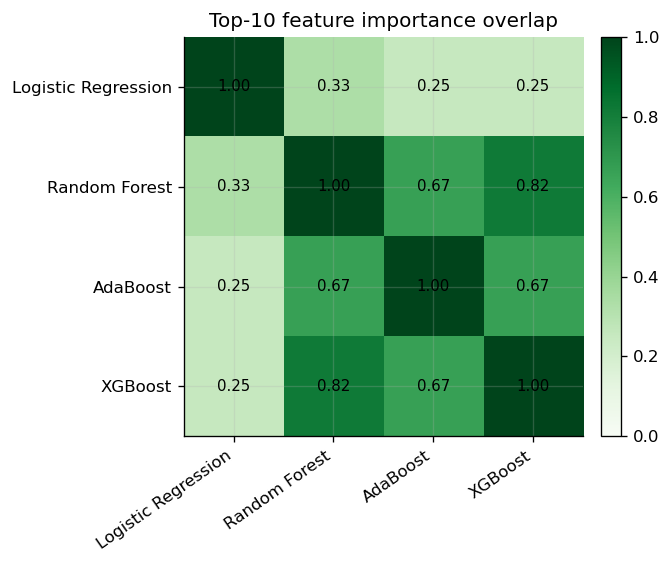

Saved feature-overlap tables and plot.


In [20]:
top10 = {
    model: set(feature_importance[(feature_importance["model"] == model) & (feature_importance["rank"] <= 10)]["feature_name"])
    for model in ML_MODELS
}
overlap = pd.DataFrame(index=ML_MODELS, columns=ML_MODELS, dtype=float)
shared_counts = pd.DataFrame(index=ML_MODELS, columns=ML_MODELS, dtype=int)
for a in ML_MODELS:
    for b in ML_MODELS:
        inter = len(top10[a] & top10[b])
        union = len(top10[a] | top10[b])
        overlap.loc[a, b] = inter / union if union else np.nan
        shared_counts.loc[a, b] = inter

overlap_labeled = overlap.rename(index=LABELS, columns=LABELS)
shared_counts_labeled = shared_counts.rename(index=LABELS, columns=LABELS)
overlap_labeled.to_csv(TBL / "report_feature_top10_overlap_jaccard.csv", index_label="model")
shared_counts_labeled.to_csv(TBL / "report_feature_top10_shared_counts.csv", index_label="model")

display(overlap_labeled.style.format("{:.3f}").set_caption("Table 8A. Jaccard overlap of each model's top-10 built-in importance features."))
display(shared_counts_labeled.style.set_caption("Table 8B. Count of shared top-10 built-in importance features."))

fig, ax = plt.subplots(figsize=(5.6, 4.8))
im = ax.imshow(overlap.values.astype(float), cmap="Greens", vmin=0, vmax=1)
ax.set_xticks(range(len(ML_MODELS)), [LABELS[m] for m in ML_MODELS], rotation=35, ha="right")
ax.set_yticks(range(len(ML_MODELS)), [LABELS[m] for m in ML_MODELS])
ax.set_title("Top-10 feature importance overlap")
for i in range(len(ML_MODELS)):
    for j in range(len(ML_MODELS)):
        ax.text(j, i, f"{overlap.values[i, j]:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(PLOT / "09_feature_top10_overlap.png")
plt.show()
print("Saved feature-overlap tables and plot.")

## Report Figure Inventory

In [21]:
inventory = pd.DataFrame({
    "figure": [
        "01_model_metrics.png",
        "02_error_rates.png",
        "03_effect_sizes_vs_rf.png",
        "04_basket_metrics.png",
        "05_model_disagreement_overlap.png",
        "06_subgroup_f1.png",
        "07_behavioral_error_tags.png",
        "08_feature_importance_top15.png",
        "09_feature_top10_overlap.png",
    ],
    "report_use": [
        "Main performance comparison",
        "FP/FN interpretation",
        "Practical effect-size discussion",
        "Per-order/basket-level interpretation",
        "Error-overlap and ensemble potential",
        "Subgroup robustness",
        "Behavioral error taxonomy",
        "Feature reliance by model",
        "Option A shared-feature design payoff",
    ],
})
inventory["path"] = inventory["figure"].map(lambda x: str(PLOT / x))
inventory.to_csv(TBL / "report_figure_inventory.csv", index=False)
display(inventory)
print("Saved:", TBL / "report_figure_inventory.csv")

,figure,report_use,path
0,01_model_metrics.png,Main performance comparison,/Users/davidlee/Desktop/NYU 2026 Spring/1003/1...
1,02_error_rates.png,FP/FN interpretation,/Users/davidlee/Desktop/NYU 2026 Spring/1003/1...
2,03_effect_sizes_vs_rf.png,Practical effect-size discussion,/Users/davidlee/Desktop/NYU 2026 Spring/1003/1...
3,04_basket_metrics.png,Per-order/basket-level interpretation,/Users/davidlee/Desktop/NYU 2026 Spring/1003/1...
4,05_model_disagreement_overlap.png,Error-overlap and ensemble potential,/Users/davidlee/Desktop/NYU 2026 Spring/1003/1...
5,06_subgroup_f1.png,Subgroup robustness,/Users/davidlee/Desktop/NYU 2026 Spring/1003/1...
6,07_behavioral_error_tags.png,Behavioral error taxonomy,/Users/davidlee/Desktop/NYU 2026 Spring/1003/1...
7,08_feature_importance_top15.png,Feature reliance by model,/Users/davidlee/Desktop/NYU 2026 Spring/1003/1...
8,09_feature_top10_overlap.png,Option A shared-feature design payoff,/Users/davidlee/Desktop/NYU 2026 Spring/1003/1...


Saved: /Users/davidlee/Desktop/NYU 2026 Spring/1003/1003_final_project/instacart/results/report_tables/report_figure_inventory.csv


## Writing Notes

Suggested final-report structure using this notebook:

1. Start with Table 1 and `01_model_metrics.png`.
2. State the metric nuance clearly: RF wins row-level F1 and ROC-AUC; Logistic Regression wins per-order F1; XGBoost wins PR-AUC.
3. Use `02_error_rates.png` and Table 2 to explain why Logistic Regression has stronger basket-level F1 despite lower row-level precision.
4. Use Table 3 to separate statistical significance from practical effect size.
5. Use Table 5 and `05_model_disagreement_overlap.png` to describe shared blind spots and possible ensembling.
6. Use Table 6 and `06_subgroup_f1.png` for subgroup conclusions.
7. Use Table 8 and feature plots as the feature-importance analysis that is supported by available artifacts.